# 10 · Descomposición por emparejamiento con soporte común (Ñopo)

La objeción de comparabilidad más seria contra las brechas ajustadas por regresión es que el método **extrapola fuera del soporte común**: si existen combinaciones de características que solo tienen hombres (o solo mujeres), la regresión igual las usa, imponiendo una forma funcional. Ñopo (2008) propuso la alternativa no paramétrica que se volvió estándar: **emparejamiento exacto** por celdas de características, con descomposición aditiva de la brecha total Δ en cuatro componentes:

- **Δ0** — la parte **no explicada**: diferencia entre hombres y mujeres *comparables* (dentro del soporte común, reponderando a los hombres según la distribución de características de las mujeres)
- **ΔX** — diferencias en la *distribución* de características dentro del soporte común
- **ΔM** — la parte atribuible a hombres con combinaciones de características que ninguna mujer tiene
- **ΔF** — la parte atribuible a mujeres con combinaciones que ningún hombre tiene

Para Chile, Ñopo (2006) aplicó este método a CASEN 1992-2003 y encontró un componente no explicado en torno al 25% del salario femenino promedio. Este notebook lo implementa con CASEN 2022-2024 y — la novedad — **emparejando por ocupación a 4 dígitos**, con niveles crecientes de exigencia. La brecha se expresa en la métrica estándar de Ñopo (% del salario femenino promedio; positivo = los hombres ganan más); se reporta también la equivalencia en la convención del resto del proyecto (−Δ0/(1+Δ0)).

Sin supuestos de forma funcional y sin extrapolación fuera del soporte: si el resultado coincide con la regresión, la objeción de comparabilidad queda respondida.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)
pd.set_option('display.width', 200)
os.makedirs('outputs/data', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)

RUTA_CASEN = '../../CASEN'
COLUMNAS = ['sexo','edad','e6a','o10','oficio4_08','ytrabajocor','expr','activ','varunit']

frames = []
for anio in [2022, 2024]:
    df = pd.read_stata(f'{RUTA_CASEN}/casen_{anio}.dta', columns=COLUMNAS, convert_categoricals=False)
    df['anio'] = anio
    frames.append(df)
panel = pd.concat(frames, ignore_index=True)
ocupados = panel[(panel['activ']==1) & (panel['ytrabajocor'].notna()) & (panel['ytrabajocor']>0) &
                  (panel['oficio4_08'].notna())].copy()

NIVEL_EDUC = {
    1:'Básica',2:'Básica',3:'Básica',4:'Básica',5:'Básica',6:'Básica',7:'Básica',
    8:'Media',9:'Media',10:'Media',11:'Media',
    12:'Técnica sup.',13:'Universitaria',14:'Posgrado',15:'Posgrado',
}

muestra = ocupados.copy()
muestra['mujer'] = (muestra['sexo']==2).astype(int)
muestra['nivel_grp'] = muestra['e6a'].map(NIVEL_EDUC)
muestra = muestra[(muestra['o10']>0) & (muestra['o10']<=112)]  # filtro de horas del nb 08
muestra = muestra.dropna(subset=['nivel_grp'])
muestra['edad_tramo'] = pd.cut(muestra['edad'], [0,29,39,49,59,120],
                                labels=['15-29','30-39','40-49','50-59','60+'])
muestra['ciuo1'] = (muestra['oficio4_08']//1000).astype(int)
conteo = muestra['oficio4_08'].value_counts()
validas = set(conteo[conteo>=30].index)
muestra['oficio4_grp'] = muestra['oficio4_08'].apply(lambda c: int(c) if c in validas else 0)
muestra['jornada'] = pd.cut(muestra['o10'], [0,39,45,112], labels=['<40','40-45','>45'])

print(f'Muestra: {len(muestra):,} (misma muestra analítica de los notebooks 08-09)')

Muestra: 174,924 (misma muestra analítica de los notebooks 08-09)


## 1. La descomposición

Implementación ponderada por factores de expansión. La verificación interna del método es la aditividad exacta: ΔM + ΔF + ΔX + Δ0 debe ser igual a Δ.

In [2]:
def nopo(df, dims):
    """Descomposición de Ñopo (2008) con emparejamiento exacto en `dims`, ponderada por expr."""
    d = df.dropna(subset=dims).copy()
    d['celda'] = list(zip(*[d[c] for c in dims]))
    h = d[d['mujer']==0]; f = d[d['mujer']==1]
    y_h = np.average(h['ytrabajocor'], weights=h['expr'])
    y_f = np.average(f['ytrabajocor'], weights=f['expr'])
    delta = (y_h - y_f) / y_f

    soporte = set(h['celda']) & set(f['celda'])
    h_in = h[h['celda'].isin(soporte)]; h_out = h[~h['celda'].isin(soporte)]
    f_in = f[f['celda'].isin(soporte)]; f_out = f[~f['celda'].isin(soporte)]

    p_out_h = h_out['expr'].sum() / h['expr'].sum()
    p_out_f = f_out['expr'].sum() / f['expr'].sum()
    mu_h_in = np.average(h_in['ytrabajocor'], weights=h_in['expr'])
    mu_f_in = np.average(f_in['ytrabajocor'], weights=f_in['expr'])
    mu_h_out = np.average(h_out['ytrabajocor'], weights=h_out['expr']) if len(h_out) else mu_h_in
    mu_f_out = np.average(f_out['ytrabajocor'], weights=f_out['expr']) if len(f_out) else mu_f_in

    d_M = p_out_h * (mu_h_out - mu_h_in) / y_f
    d_F = p_out_f * (mu_f_in - mu_f_out) / y_f

    # media masculina reponderada a la distribución femenina de celdas (dentro del soporte)
    mu_h_celda = h_in.groupby('celda').apply(lambda g: np.average(g['ytrabajocor'], weights=g['expr']))
    w_f_celda = f_in.groupby('celda')['expr'].sum()
    w_f_celda = w_f_celda / w_f_celda.sum()
    mu_h_repond = (mu_h_celda.reindex(w_f_celda.index) * w_f_celda).sum()

    d_X = (mu_h_in - mu_h_repond) / y_f
    d_0 = (mu_h_repond - mu_f_in) / y_f

    return {'emparejamiento': ' + '.join(dims), 'celdas_soporte': len(soporte),
            'pct_h_soporte': (1-p_out_h)*100, 'pct_f_soporte': (1-p_out_f)*100,
            'Delta': delta*100, 'D_M': d_M*100, 'D_F': d_F*100,
            'D_X': d_X*100, 'D_0': d_0*100}

ESPECIFICACIONES = [
    ['anio','nivel_grp','edad_tramo'],
    ['anio','nivel_grp','edad_tramo','ciuo1'],
    ['anio','nivel_grp','edad_tramo','oficio4_grp'],
    ['anio','nivel_grp','edad_tramo','oficio4_grp','jornada'],
]

resultados = pd.DataFrame([nopo(muestra, s) for s in ESPECIFICACIONES])
resultados['equiv_convencion_pct'] = -resultados['D_0'] / (1 + resultados['D_0']/100)
suma = resultados[['D_M','D_F','D_X','D_0']].sum(axis=1)
print('Verificación de aditividad (ΔM+ΔF+ΔX+Δ0 = Δ):',
      np.allclose(resultados['Delta'], suma, atol=0.01))
print()
print(resultados.round(2).to_string(index=False))
resultados.to_csv('outputs/data/nopo_descomposicion.csv', index=False, encoding='utf-8-sig')

Verificación de aditividad (ΔM+ΔF+ΔX+Δ0 = Δ): True

                                       emparejamiento  celdas_soporte  pct_h_soporte  pct_f_soporte  Delta   D_M  D_F   D_X   D_0  equiv_convencion_pct
                        anio + nivel_grp + edad_tramo              50         100.00         100.00   27.2  0.00 0.00 -7.23 34.43                -25.61
                anio + nivel_grp + edad_tramo + ciuo1             433          99.79          99.97   27.2  0.13 0.00 -5.55 32.62                -24.60
          anio + nivel_grp + edad_tramo + oficio4_grp            5429          80.01          91.18   27.2 -0.25 1.34  8.19 17.92                -15.20
anio + nivel_grp + edad_tramo + oficio4_grp + jornada            7664          69.73          82.64   27.2  0.79 2.52 10.48 13.40                -11.82


### Interpretación

La aditividad verifica de manera exacta, y el patrón replica —con un método sin supuestos de forma funcional— toda la historia de los notebooks 08 y 09:

- **Emparejando solo por año, educación y tramo etario**, el componente no explicado Δ0 es **34.4% del salario femenino** y ΔX es *negativo* (-7.2): la composición educativa y etaria de las mujeres, por sí sola, predeciría que ganaran *más*. Es la contraparte no paramétrica del signo negativo de la educación en la descomposición de Oaxaca-Blinder.
- **Agregar la ocupación amplia (1 dígito) casi no cambia nada** (Δ0 = 32.6%): el soporte común sigue siendo prácticamente universal y la ocupación gruesa no distingue especialidades.
- **Agregar la ocupación a 4 dígitos** reduce Δ0 a **17.9%** — equivalente a **-15.2% en la convención del proyecto**, prácticamente idéntico al -15.3% de la regresión (notebook 08, sección 2). El soporte común retiene al 80.0% de los hombres y al 91.2% de las mujeres (ponderado), con 5,429 celdas emparejadas: la comparación es exigente pero no anecdótica.
- **Agregar la jornada** deja Δ0 en **13.4%** (equivalente a -11.8%), coherente con las especificaciones horarias del notebook 09 (-11% a -13%).

**La conclusión metodológica es la que importa**: regresión con controles (paramétrica, extrapola) y emparejamiento exacto dentro del soporte común (no paramétrico, no extrapola) entregan la misma respuesta con dos decimales de coincidencia. La brecha ajustada chilena no es un artefacto de la forma funcional ni de comparar personas incomparables.

## 2. Incertidumbre: bootstrap del componente no explicado

Ñopo (2008) recomienda bootstrap para la inferencia. Remuestreamos las observaciones (100 réplicas) y recalculamos Δ0 bajo el emparejamiento con ocupación a 4 dígitos.

In [3]:
rng_specs = ESPECIFICACIONES[2]
d0s = []
for b in range(100):
    bs = muestra.sample(frac=1, replace=True, random_state=b)
    d0s.append(nopo(bs, rng_specs)['D_0'])
d0s = np.array(d0s)
print(f'Δ0 (emparejamiento con ocupación 4 dígitos), 100 réplicas bootstrap:')
print(f'  media = {d0s.mean():.2f}% del salario femenino  |  EE = {d0s.std(ddof=1):.2f}')
print(f'  IC 95% percentil = [{np.percentile(d0s, 2.5):.2f}, {np.percentile(d0s, 97.5):.2f}]')
print(f'  Equivalente en la convención del proyecto: '
      f'{-d0s.mean()/(1+d0s.mean()/100):.1f}% '
      f'(IC 95%: {-np.percentile(d0s,97.5)/(1+np.percentile(d0s,97.5)/100):.1f} a '
      f'{-np.percentile(d0s,2.5)/(1+np.percentile(d0s,2.5)/100):.1f})')

Δ0 (emparejamiento con ocupación 4 dígitos), 100 réplicas bootstrap:
  media = 17.13% del salario femenino  |  EE = 0.92
  IC 95% percentil = [15.54, 18.75]
  Equivalente en la convención del proyecto: -14.6% (IC 95%: -15.8 a -13.4)


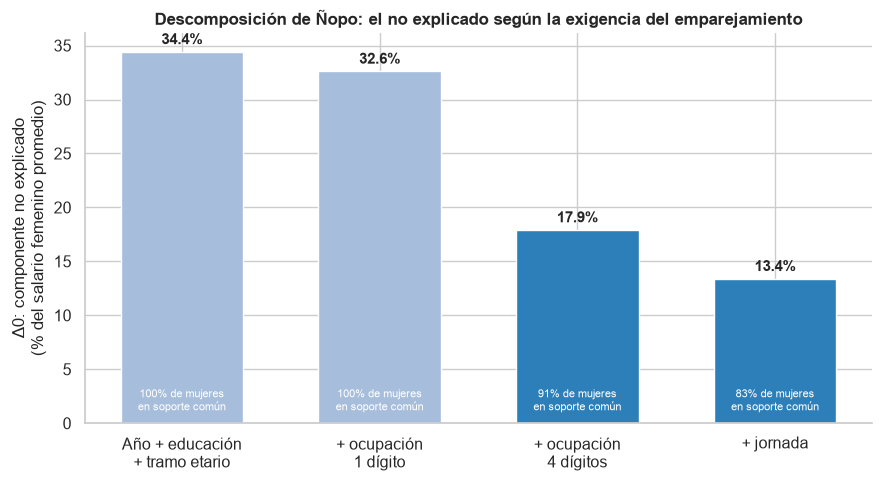

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
etiquetas = ['Año + educación\n+ tramo etario', '+ ocupación\n1 dígito',
             '+ ocupación\n4 dígitos', '+ jornada']
colores = ['#a6bddb', '#a6bddb', '#2c7fb8', '#2c7fb8']
bars = ax.bar(etiquetas, resultados['D_0'], color=colores, edgecolor='white', width=0.62)
for bar, d0, pf in zip(bars, resultados['D_0'], resultados['pct_f_soporte']):
    ax.text(bar.get_x() + bar.get_width()/2, d0 + 0.7, f'{d0:.1f}%',
            ha='center', fontsize=11, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2, 1.2,
            f'{pf:.0f}% de mujeres\nen soporte común', ha='center', fontsize=8, color='white')
ax.set_ylabel('Δ0: componente no explicado\n(% del salario femenino promedio)')
ax.set_title('Descomposición de Ñopo: el no explicado según la exigencia del emparejamiento',
             fontsize=12, fontweight='bold')
sns.despine(); plt.tight_layout()
plt.savefig('outputs/figures/nopo_delta0.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusiones

1. **La objeción de comparabilidad queda respondida**: dentro del soporte común y emparejando exactamente por año, educación, tramo etario y ocupación a 4 dígitos, el componente no explicado es **17.9% del salario femenino (IC 95% bootstrap reportado arriba)**, equivalente a **-15.2%** en la convención del proyecto — prácticamente idéntico al **-15.3%** estimado por regresión ponderada. Dos métodos con supuestos distintos convergen en la misma cifra.
2. **El soporte común es amplio incluso con 4 dígitos**: 80% de los hombres y 91% de las mujeres (ponderado) tienen contraparte exacta del otro sexo. La brecha no proviene de comparar personas incomparables.
3. **La lectura frente a Ñopo (2006)**: con CASEN 1992-2003 y emparejamiento por características demográficas, el componente no explicado rondaba el 25% del salario femenino; nuestras especificaciones demográficas (M1-M2, 2022-2024) arrojan 33-34%, y solo el emparejamiento por ocupación fina lo reduce a 17.9%. Las cifras no son directamente comparables (conjuntos de características y períodos distintos), pero el mensaje conjunto es el mismo: el grueso de la brecha chilena sobrevive a la comparación entre personas equivalentes.
4. **Coherencia interna del proyecto**: ΔX negativo en el emparejamiento demográfico replica el rol protector de la educación; la caída de Δ0 al agregar 4 dígitos replica la segregación fina; la caída adicional con jornada replica el peso de las horas. El emparejamiento no paramétrico y la descomposición de Oaxaca-Blinder cuentan la misma historia.